# ODE Integration Method Grid Search

Compare **Euler**, **Midpoint**, **RK4**, and **Dopri5** (adaptive) integration methods
with **uniform** vs **sway** time schedules, across CFG scales **1.0**, **1.2**, **1.5**
on a single model checkpoint.

## Visualization Libraries Used

| Library | Purpose |
|---|---|
| **matplotlib** | Mel spectrogram heatmaps (`imshow`) and difference plots |
| **IPython.display.Audio** | Inline audio playback widgets in the notebook |
| **IPython.display.HTML** | Rich HTML rendering for structured audio grids and section headers |
| **pandas** | Summary metrics tables (MSE, MAE per configuration) |
| **ipywidgets** *(optional)* | Interactive Tab widgets for navigating between samples without scrolling — install with `pip install ipywidgets` if not available |

## Samples

- **Validation chunks**: Same held-out split as `validation_viewer.ipynb` (deterministic, seed=42)
- **Let It Go demo**: Full song inference using the pipeline's USTX → mel extraction

In [1]:
# ── Configuration ──

CHECKPOINT = "../VocaloFlow/checkpoints/4-23-embed/checkpoint_65000.pt"
MODEL_LABEL = "4-23 Embed"

MANIFEST_PATH = "../Data/Rachie/manifest.csv"
DATA_DIR = "../Data/Rachie"

# Let It Go demo song
LET_IT_GO_USTX = "../demo/let_it_go/let_it_go.ustx"
LET_IT_GO_PRIOR_WAV = "../demo/let_it_go/prior_let_it_go.wav"

N_SAMPLES = 4  # validation samples (keep small — many inferences each)
DEVICE = "auto"

# Validation split (matches training config)
MAX_DTW_COST = 100.0
VAL_FRACTION = 0.05
SEED = 42

# ── Grid search axes ──
METHODS = ["euler", "midpoint", "rk4", "dopri5"]
TIME_SCHEDULES = ["uniform", "sway"]
CFG_SCALES = [1.0, 1.2, 1.5]

# Build (method, schedule) row configs — dopri5 ignores schedule, so only one entry
CONFIG_ROWS = []
for method in METHODS:
    if method == "dopri5":
        CONFIG_ROWS.append((method, "adaptive"))
    else:
        for sched in TIME_SCHEDULES:
            CONFIG_ROWS.append((method, sched))
ROW_LABELS = [f"{m} ({s})" for m, s in CONFIG_ROWS]

# ODE settings
NUM_ODE_STEPS = 32
SWAY_COEFF = -1.0
CHUNK_SIZE = 256
OVERLAP = 16

# Dopri5 tolerances
ATOL = 1e-5
RTOL = 1e-5

# Mel normalization constants (SoulX-Singer z-score)
MEL_MEAN = -4.92
MEL_VAR = 8.14
SR = 24000
HOP = 480

print(f"Grid: {len(CONFIG_ROWS)} method/schedule rows × {len(CFG_SCALES)} CFG scales "
      f"= {len(CONFIG_ROWS) * len(CFG_SCALES)} configs per sample")
print(f"Rows: {ROW_LABELS}")

Grid: 7 method/schedule rows × 3 CFG scales = 21 configs per sample
Rows: ['euler (uniform)', 'euler (sway)', 'midpoint (uniform)', 'midpoint (sway)', 'rk4 (uniform)', 'rk4 (sway)', 'dopri5 (adaptive)']


In [2]:
import sys, os, math, time, io, base64, json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from IPython.display import Audio, display, HTML
import soundfile as sf

try:
    import ipywidgets as widgets
    HAS_WIDGETS = True
    print("ipywidgets available — using tabbed navigation")
except ImportError:
    HAS_WIDGETS = False
    print("ipywidgets not installed — falling back to flat layout. "
          "Install with: pip install ipywidgets")

# ── Path setup (mirrors VocaloFlow/inference/pipeline.py) ──
REPO_ROOT = str(Path("..").resolve())
VOCALOFLOW_DIR = os.path.join(REPO_ROOT, "VocaloFlow")
SOULX_DIR = os.path.join(REPO_ROOT, "SoulX-Singer")

for p in [REPO_ROOT, VOCALOFLOW_DIR, SOULX_DIR]:
    if p not in sys.path:
        sys.path.insert(0, p)

from utils.data_helpers import load_manifest, filter_manifest, split_by_song
from utils.resample import resolve_phoneme_indirection, resample_1d
from inference.inference import sample_ode
from inference.pipeline import (
    load_model, infer_chunked, mel_to_wav,
    parse_ustx, extract_prior_mel, extract_or_load_f0,
    build_phoneme_ids, build_plbert_frame_features,
    get_voiced_mask,
)

# ── Resolve device ──
if DEVICE == "auto":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
else:
    device = torch.device(DEVICE)
print(f"Device: {device}")


# ── Helpers ──

def denormalize_mel(mel):
    return mel * math.sqrt(MEL_VAR) + MEL_MEAN


def load_lyrics(sample):
    """Return lyrics string for a sample."""
    chunk_words_path = os.path.join(sample["chunk_dir"], "chunk_words.json")
    if os.path.exists(chunk_words_path):
        with open(chunk_words_path) as f:
            return " ".join(json.load(f))
    return sample.get("lyrics", "")


def load_chunk_inputs(row, use_plbert):
    """Load all model inputs for a single validation chunk."""
    prior_mel = np.load(row["prior_mel_path"]).astype(np.float32)
    target_mel = np.load(row["target_mel_path"]).astype(np.float32)
    f0 = np.load(row["f0_path"]).astype(np.float32)
    voicing = np.load(row["voicing_path"]).astype(np.float32)

    chunk_dir = os.path.dirname(row["prior_mel_path"])
    phoneme_mask = np.load(row["phoneme_mask_path"]).astype(np.int64)
    phoneme_ids_raw = np.load(os.path.join(chunk_dir, "phoneme_ids.npy")).astype(np.int64)
    resolved = resolve_phoneme_indirection(phoneme_ids_raw, phoneme_mask)

    T = target_mel.shape[0]

    def match_1d(x, n):
        return x[:n] if len(x) >= n else np.pad(x, (0, n - len(x)))

    def match_2d(x, n):
        return x[:n] if x.shape[0] >= n else np.pad(x, ((0, n - x.shape[0]), (0, 0)))

    prior_mel = match_2d(prior_mel, T)
    f0 = match_1d(f0, T)
    voicing = match_1d(voicing, T)
    resolved = match_1d(resolved, T)

    result = {
        "prior_mel": prior_mel, "target_mel": target_mel,
        "f0": f0, "voicing": voicing, "phoneme_ids": resolved,
        "chunk_dir": chunk_dir,
    }

    if use_plbert:
        plbert_path = os.path.join(chunk_dir, "plbert_features.npy")
        if os.path.exists(plbert_path):
            plbert_feats = np.load(plbert_path).astype(np.float32)
            mask_clipped = np.clip(phoneme_mask, 0, len(plbert_feats) - 1)
            plbert_frame = plbert_feats[mask_clipped]
            plbert_frame = match_2d(plbert_frame, T)
            result["plbert_features"] = plbert_frame
        else:
            result["plbert_features"] = None

    return result


def audio_to_html(audio_array, rate=24000, label=""):
    """Convert audio numpy array to an inline HTML audio player."""
    buf = io.BytesIO()
    sf.write(buf, audio_array, rate, format="WAV")
    b64 = base64.b64encode(buf.getvalue()).decode("ascii")
    return (
        f'<div style="margin:2px 0"><small>{label}</small><br>'
        f'<audio controls preload="none" style="width:220px;height:28px">'
        f'<source src="data:audio/wav;base64,{b64}" type="audio/wav">'
        f'</audio></div>'
    )


def file_audio_html(path, label=""):
    """HTML audio player from a file path."""
    abs_path = os.path.abspath(path)
    return (
        f'<div style="margin:2px 0"><small>{label}</small><br>'
        f'<audio controls preload="none" style="width:220px;height:28px">'
        f'<source src="file:///{abs_path}" type="audio/wav">'
        f'</audio></div>'
    )

ipywidgets available — using tabbed navigation


c:\Users\archi\miniconda3\envs\vocaloflow\Lib\site-packages\g2pM\g2pM.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  state_dict = pickle.load(open(os.path.dirname(os.path.abspath(__file__)) + '/np_ckpt.pkl', 'rb'))


Device: cuda


In [3]:
# ── Load model ──

model = load_model(CHECKPOINT, device)
print(f"Model: {MODEL_LABEL}")
print(f"  use_plbert:           {model.config.use_plbert}")
print(f"  use_speaker_embedding: {model.config.use_speaker_embedding}")

speaker_embedding = None
if model.config.use_speaker_embedding:
    spk_path = os.path.join(REPO_ROOT, "SpeakerEmbedding", "embeddings", "Rachie", "speaker_embedding.pt")
    if os.path.exists(spk_path):
        speaker_embedding = torch.load(spk_path, weights_only=True).float().unsqueeze(0).to(device)
        print(f"  Speaker embedding:     {speaker_embedding.shape}")

use_plbert = model.config.use_plbert

[pipeline] Loaded model from step 65000 (51,133,824 params, using ema_model_state_dict)
Model: 4-23 Embed
  use_plbert:           True
  use_speaker_embedding: True
  Speaker embedding:     torch.Size([1, 192])


In [4]:
# ── Load validation samples ──

manifest = load_manifest(MANIFEST_PATH, DATA_DIR)
filtered = filter_manifest(manifest, max_dtw_cost=MAX_DTW_COST)
train_df, val_df = split_by_song(filtered, val_fraction=VAL_FRACTION, seed=SEED)

n_val = min(N_SAMPLES, len(val_df))
print(f"Validation set: {len(val_df)} chunks from {val_df['dali_id'].nunique()} songs")
print(f"Using {n_val} validation samples")

# Pre-load all validation inputs
val_samples = []
for i in range(n_val):
    row = val_df.iloc[i]
    inputs = load_chunk_inputs(row, use_plbert)
    inputs["label"] = f"Val {i+1}: {row['dali_id'][:8]}…/{row['chunk_name']}"
    inputs["has_target"] = True
    val_samples.append(inputs)
    print(f"  Loaded: {inputs['label']}  T={inputs['target_mel'].shape[0]}")

[data_helpers] Filtered 160467 -> 140789 chunks (max_dtw_cost=100.0)
[data_helpers] Split: 133770 train chunks (2736 songs), 7019 val chunks (144 songs)
Validation set: 7019 chunks from 144 songs
Using 4 validation samples
  Loaded: Val 1: 017fdad7…/line_0  T=50
  Loaded: Val 2: 017fdad7…/line_1  T=87
  Loaded: Val 3: 017fdad7…/line_10  T=123
  Loaded: Val 4: 017fdad7…/line_12  T=160


In [5]:
# ── Prepare Let It Go demo inputs ──

_PHONESET = os.path.join(SOULX_DIR, "soulxsinger", "utils", "phoneme", "phone_set.json")
_PLBERT_DIR = os.path.join(REPO_ROOT, "PL-BERT")

notes_data = parse_ustx(LET_IT_GO_USTX)
lig_prior_mel = extract_prior_mel(LET_IT_GO_PRIOR_WAV)
T_lig = lig_prior_mel.shape[0]
print(f"Let It Go: T={T_lig} frames ({T_lig * HOP / SR:.1f}s)")

lig_f0_raw = extract_or_load_f0(
    f0_path=None, wav_path=LET_IT_GO_PRIOR_WAV,
    rmvpe_model_path=os.path.join(SOULX_DIR, "pretrained_models", "rmvpe", "rmvpe.pt"),
    device=str(device), notes_data=notes_data, total_frames=T_lig,
)
lig_f0 = resample_1d(lig_f0_raw, T_lig, mode="linear").numpy()
lig_voicing = get_voiced_mask(lig_f0).astype(np.float32)
lig_phoneme_ids = build_phoneme_ids(
    notes_data["notes"], notes_data["ms_per_tick"], T_lig, _PHONESET
)

lig_plbert = None
if use_plbert:
    lig_plbert = build_plbert_frame_features(
        notes_data["notes"], notes_data["ms_per_tick"], T_lig,
        _PHONESET, plbert_dir=_PLBERT_DIR, device=str(device),
    )

# Extract lyrics from USTX notes
_skip = {"", "R", "r", "+", "-"}
lig_lyrics = " ".join(
    str(n.get("lyric", ""))
    for n in notes_data["notes"]
    if str(n.get("lyric", "")) not in _skip
)

lig_sample = {
    "label": "Let It Go (full song)",
    "prior_mel": lig_prior_mel,
    "target_mel": None,
    "f0": lig_f0,
    "voicing": lig_voicing,
    "phoneme_ids": lig_phoneme_ids,
    "plbert_features": lig_plbert,
    "chunk_dir": os.path.dirname(os.path.abspath(LET_IT_GO_PRIOR_WAV)),
    "has_target": False,
    "lyrics": lig_lyrics,
}

all_samples = val_samples + [lig_sample]
print(f"\nTotal samples: {len(all_samples)} ({n_val} validation + 1 demo)")
print(f"Let It Go lyrics: {lig_lyrics[:80]}...")

[pipeline] Parsed 17 notes from let_it_go.ustx (bpm=120.0, resolution=480)
[pipeline] Extracted prior mel: (425, 128) from prior_let_it_go.wav
Let It Go: T=425 frames (8.5s)
[pipeline] Synthesized F0 from MIDI pitches: 425 frames, voiced ratio=77.18%
[pipeline] Built phoneme IDs: 425 frames, vocab used: 27 unique tokens
[pipeline] Built PL-BERT features: (425, 768), non-zero frames: 169/425

Total samples: 5 (4 validation + 1 demo)
Let It Go lyrics: the snow glows white True the mountain tonight not a footprint to be seen...


## Run Inference Grid

For each sample, run all **7 method/schedule combos × 3 CFG scales = 21 configurations**.
Results are stored as `results[sample_idx][(method, schedule, cfg)]` = output mel `(T, 128)`.

In [6]:
# ── Run inference grid ──

results = []  # results[sample_idx][(method, schedule, cfg)] = output_mel
timings = []  # same structure but wall-clock seconds

n_configs = len(CONFIG_ROWS) * len(CFG_SCALES)

for si, sample in enumerate(all_samples):
    print(f"\n{'='*60}")
    print(f"Sample {si+1}/{len(all_samples)}: {sample['label']}")
    print(f"{'='*60}")

    sample_results = {}
    sample_timings = {}
    plbert = sample.get("plbert_features") if use_plbert else None

    for ri, (method, sched) in enumerate(CONFIG_ROWS):
        for ci, cfg in enumerate(CFG_SCALES):
            config_idx = ri * len(CFG_SCALES) + ci + 1
            tag = f"{method}/{sched}/cfg={cfg}"
            print(f"  [{config_idx:2d}/{n_configs}] {tag} ...", end=" ", flush=True)

            # dopri5 ignores schedule; fixed-step methods use it
            ts = "uniform" if sched == "adaptive" else sched

            t0 = time.time()
            output_mel = infer_chunked(
                model, sample["prior_mel"], sample["f0"],
                sample["voicing"], sample["phoneme_ids"],
                chunk_size=CHUNK_SIZE, overlap=OVERLAP,
                num_steps=NUM_ODE_STEPS, method=method,
                device=device, cfg_scale=cfg,
                plbert_features=plbert,
                speaker_embedding=speaker_embedding,
                time_schedule=ts, sway_coeff=SWAY_COEFF,
                atol=ATOL, rtol=RTOL,
            )
            elapsed = time.time() - t0

            sample_results[(method, sched, cfg)] = output_mel
            sample_timings[(method, sched, cfg)] = elapsed
            print(f"{elapsed:.1f}s")

    results.append(sample_results)
    timings.append(sample_timings)

print(f"\nAll inference complete.")


Sample 1/5: Val 1: 017fdad7…/line_0
  [ 1/21] euler/uniform/cfg=1.0 ... [pipeline] Running inference: 1 chunk(s) (T=50, chunk=256, overlap=16)
  [ode] step   0/32  t=0.0000  |v| mean=0.355417  max=4.231556  |x_t| mean=0.1861
  [ode] step   8/32  t=0.2500  |v| mean=0.695044  max=4.198115  |x_t| mean=0.2820
  [ode] step  16/32  t=0.5000  |v| mean=0.686280  max=4.205739  |x_t| mean=0.3770
  [ode] step  31/32  t=0.9688  |v| mean=0.665645  max=4.230274  |x_t| mean=0.5906
  chunk 1/1
2.1s
  [ 2/21] euler/uniform/cfg=1.2 ... [pipeline] Running inference: 1 chunk(s) (T=50, chunk=256, overlap=16)
  [ode] step   0/32  t=0.0000  |v| mean=0.355863  max=4.332934  |x_t| mean=0.1861
  [ode] step   8/32  t=0.2500  |v| mean=0.686086  max=4.225116  |x_t| mean=0.2792
  [ode] step  16/32  t=0.5000  |v| mean=0.678625  max=4.252698  |x_t| mean=0.3721
  [ode] step  31/32  t=0.9688  |v| mean=0.657563  max=4.242223  |x_t| mean=0.5820
  chunk 1/1
2.9s
  [ 3/21] euler/uniform/cfg=1.5 ... [pipeline] Running infe

## Mel Spectrogram Comparison

For each sample: a grid of mel spectrograms with **method/schedule combos as rows** and **CFG scales as columns**.
Prior and Target (when available) are shown in the top row for reference.

Use the **tabs** to switch between samples (requires `ipywidgets`).

In [7]:
# ── Mel spectrogram grids (tabbed by sample) ──

def _render_mel_grid(si, sample):
    """Render mel spectrogram grid for one sample into the current output context."""
    has_target = sample["has_target"]
    prior_mel = sample["prior_mel"]
    target_mel = sample["target_mel"]
    sample_results = results[si]

    n_rows = len(CONFIG_ROWS)
    n_cfg = len(CFG_SCALES)

    all_mels = [prior_mel] + list(sample_results.values())
    if has_target:
        all_mels.append(target_mel)
    vmin = min(m.min() for m in all_mels)
    vmax = max(m.max() for m in all_mels)

    fig = plt.figure(figsize=(6 * n_cfg, 3.2 * (n_rows + 1)))
    gs = GridSpec(n_rows + 1, n_cfg, figure=fig, hspace=0.35, wspace=0.15)

    if has_target:
        ax_prior = fig.add_subplot(gs[0, :n_cfg // 2 + n_cfg % 2])
        ax_target = fig.add_subplot(gs[0, n_cfg // 2 + n_cfg % 2:])
        for ax, mel, title in [
            (ax_prior, prior_mel, "Prior (OpenUtau)"),
            (ax_target, target_mel, "SoulX Target"),
        ]:
            t_end = mel.shape[0] * HOP / SR
            ax.imshow(mel.T, origin="lower", aspect="auto", cmap="magma",
                      vmin=vmin, vmax=vmax, extent=[0, t_end, 0, 128])
            ax.set_title(title, fontsize=10, fontweight="bold")
            ax.set_ylabel("Mel bin")
    else:
        ax_prior = fig.add_subplot(gs[0, :])
        t_end = prior_mel.shape[0] * HOP / SR
        ax_prior.imshow(prior_mel.T, origin="lower", aspect="auto", cmap="magma",
                        vmin=vmin, vmax=vmax, extent=[0, t_end, 0, 128])
        ax_prior.set_title("Prior (OpenUtau)", fontsize=10, fontweight="bold")
        ax_prior.set_ylabel("Mel bin")

    for ri, ((method, sched), row_label) in enumerate(zip(CONFIG_ROWS, ROW_LABELS)):
        for ci, cfg in enumerate(CFG_SCALES):
            ax = fig.add_subplot(gs[ri + 1, ci])
            mel = sample_results[(method, sched, cfg)]
            t_end = mel.shape[0] * HOP / SR
            im = ax.imshow(mel.T, origin="lower", aspect="auto", cmap="magma",
                           vmin=vmin, vmax=vmax, extent=[0, t_end, 0, 128])
            title = f"{row_label}  |  CFG {cfg}"
            if has_target:
                mae = np.abs(mel - target_mel).mean()
                title += f"  |  MAE {mae:.3f}"
            ax.set_title(title, fontsize=9)
            if ci == 0:
                ax.set_ylabel("Mel bin")
            else:
                ax.set_yticklabels([])
            if ri == n_rows - 1:
                ax.set_xlabel("Time (s)")

    fig.suptitle(sample["label"], fontsize=13, fontweight="bold", y=1.01)
    fig.colorbar(im, ax=fig.axes, shrink=0.6, pad=0.02, label="Amplitude")
    plt.show()


if HAS_WIDGETS:
    tab_outputs = []
    tab_titles = []
    for si, sample in enumerate(all_samples):
        out = widgets.Output()
        with out:
            _render_mel_grid(si, sample)
        tab_outputs.append(out)
        tab_titles.append(sample["label"])

    tabs = widgets.Tab(children=tab_outputs)
    for i, title in enumerate(tab_titles):
        tabs.set_title(i, title)
    display(tabs)
else:
    for si, sample in enumerate(all_samples):
        display(HTML(f"<h3>Sample {si+1}: {sample['label']}</h3>"))
        _render_mel_grid(si, sample)

## Difference Plots (Validation Samples Only)

Shows `Generated - Target` for each method/CFG combination. Blue = under-predicted, red = over-predicted.
Only displayed for validation samples where a ground-truth target mel exists.

Use the **tabs** to switch between samples.

In [8]:
# ── Difference plots (validation only, tabbed by sample) ──

def _render_diff_grid(si, sample):
    """Render difference heatmaps for one sample into the current output context."""
    target_mel = sample["target_mel"]
    sample_results = results[si]

    n_rows = len(CONFIG_ROWS)
    n_cfg = len(CFG_SCALES)

    fig, axes = plt.subplots(n_rows, n_cfg, figsize=(6 * n_cfg, 3 * n_rows))

    all_diffs = [sample_results[(m, s, c)] - target_mel
                 for m, s in CONFIG_ROWS for c in CFG_SCALES]
    vlim = max(np.abs(d).max() for d in all_diffs)

    for ri, ((method, sched), row_label) in enumerate(zip(CONFIG_ROWS, ROW_LABELS)):
        for ci, cfg in enumerate(CFG_SCALES):
            ax = axes[ri, ci]
            diff = sample_results[(method, sched, cfg)] - target_mel
            t_end = diff.shape[0] * HOP / SR
            im = ax.imshow(
                diff.T, origin="lower", aspect="auto",
                cmap="coolwarm", vmin=-vlim, vmax=vlim,
                extent=[0, t_end, 0, 128],
            )
            mae = np.abs(diff).mean()
            ax.set_title(f"{row_label} | CFG {cfg} | MAE {mae:.3f}", fontsize=9)
            if ci == 0:
                ax.set_ylabel("Mel bin")
            else:
                ax.set_yticklabels([])
            if ri == n_rows - 1:
                ax.set_xlabel("Time (s)")

    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, pad=0.02, label="Δ amplitude")
    fig.suptitle(f"Error: {sample['label']}", fontsize=12, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


# Only show for samples that have a target
val_indices = [si for si, s in enumerate(all_samples) if s["has_target"]]

if HAS_WIDGETS and len(val_indices) > 0:
    tab_outputs = []
    tab_titles = []
    for si in val_indices:
        sample = all_samples[si]
        out = widgets.Output()
        with out:
            _render_diff_grid(si, sample)
        tab_outputs.append(out)
        tab_titles.append(sample["label"])

    tabs = widgets.Tab(children=tab_outputs)
    for i, title in enumerate(tab_titles):
        tabs.set_title(i, title)
    display(tabs)
else:
    for si in val_indices:
        sample = all_samples[si]
        display(HTML(f"<h3>Δ Target — {sample['label']}</h3>"))
        _render_diff_grid(si, sample)

## Audio Comparison

Tabbed audio player grid — each tab is one sample. Within each tab:
- **Lyrics** shown at the top (when available)
- **Prior / Target** reference audio
- **Method/schedule rows x CFG columns** grid of generated audio players

In [9]:
# ── Audio comparison grids (tabbed by sample) ──

def _render_audio_grid(si, sample):
    """Render audio comparison grid for one sample into the current output context."""
    # ── Lyrics ──
    lyrics = load_lyrics(sample)
    if lyrics:
        display(HTML(
            f'<div style="background:#f0f0f0;padding:8px 12px;border-radius:6px;'
            f'margin-bottom:10px;font-style:italic;color:#333">'
            f'<b>Lyrics:</b> {lyrics}</div>'
        ))

    sample_results = results[si]

    # ── Reference audio (use native sample rate from the file) ──
    ref_html = '<div style="display:flex;gap:30px;margin-bottom:10px">'

    prior_wav_path = os.path.join(sample["chunk_dir"], "prior.wav")
    if not os.path.exists(prior_wav_path):
        prior_wav_path = os.path.join(sample["chunk_dir"], "prior_let_it_go.wav")

    if os.path.exists(prior_wav_path):
        prior_audio, prior_sr = sf.read(prior_wav_path)
        ref_html += audio_to_html(prior_audio, prior_sr, "Prior (OpenUtau)")

    if sample["has_target"]:
        target_wav_path = os.path.join(sample["chunk_dir"], "target.wav")
        if os.path.exists(target_wav_path):
            target_audio, target_sr = sf.read(target_wav_path)
            ref_html += audio_to_html(target_audio, target_sr, "SoulX Target")

    ref_html += '</div>'
    display(HTML(ref_html))

    # ── Grid table: method/schedule (rows) x CFG (columns) ──
    table = '<table style="border-collapse:collapse">'
    table += '<tr><th style="padding:4px 8px"></th>'
    for cfg in CFG_SCALES:
        table += f'<th style="padding:4px 8px;text-align:center">CFG {cfg}</th>'
    table += '</tr>'

    for (method, sched), row_label in zip(CONFIG_ROWS, ROW_LABELS):
        table += f'<tr><td style="padding:4px 8px;font-weight:bold;vertical-align:top">{row_label}</td>'
        for cfg in CFG_SCALES:
            mel = sample_results[(method, sched, cfg)]
            audio = mel_to_wav(mel)
            cell_html = audio_to_html(audio, SR)
            table += f'<td style="padding:4px 8px">{cell_html}</td>'
        table += '</tr>'

    table += '</table>'
    display(HTML(table))


if HAS_WIDGETS:
    tab_outputs = []
    tab_titles = []
    for si, sample in enumerate(all_samples):
        out = widgets.Output()
        with out:
            _render_audio_grid(si, sample)
        tab_outputs.append(out)
        tab_titles.append(sample["label"])

    tabs = widgets.Tab(children=tab_outputs)
    for i, title in enumerate(tab_titles):
        tabs.set_title(i, title)
    display(tabs)
else:
    for si, sample in enumerate(all_samples):
        display(HTML(f"<h3>Audio — {sample['label']}</h3>"))
        _render_audio_grid(si, sample)
        display(HTML("<hr>"))

## Summary Metrics

Aggregated **MAE** and **MSE** across all validation samples (with ground-truth targets),
plus **wall-clock time** for every configuration.

In [10]:
# ── Summary metrics table ──

rows = []
for si, sample in enumerate(all_samples):
    sample_results = results[si]
    sample_timings_dict = timings[si]
    target_mel = sample["target_mel"]

    for (method, sched), row_label in zip(CONFIG_ROWS, ROW_LABELS):
        for cfg in CFG_SCALES:
            mel = sample_results[(method, sched, cfg)]
            row = {
                "Sample": sample["label"],
                "Method": row_label,
                "CFG": cfg,
                "Time (s)": round(sample_timings_dict[(method, sched, cfg)], 2),
            }
            if target_mel is not None:
                diff = mel - target_mel
                row["MAE"] = round(np.abs(diff).mean(), 4)
                row["MSE"] = round((diff ** 2).mean(), 4)
                row["Max |Δ|"] = round(np.abs(diff).max(), 4)
            else:
                row["MAE"] = None
                row["MSE"] = None
                row["Max |Δ|"] = None
            rows.append(row)

df = pd.DataFrame(rows)
display(HTML("<h3>Per-Sample Results</h3>"))
display(df.style.format({
    "MAE": "{:.4f}", "MSE": "{:.4f}", "Max |Δ|": "{:.4f}", "Time (s)": "{:.2f}",
    "CFG": "{:.1f}",
}, na_rep="—").set_properties(**{"text-align": "center"}).hide(axis="index"))

# ── Aggregated across validation samples ──
val_df_metrics = df[df["MAE"].notna()].copy()
if len(val_df_metrics) > 0:
    agg = val_df_metrics.groupby(["Method", "CFG"]).agg(
        MAE_mean=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        MSE_mean=("MSE", "mean"),
        Time_mean=("Time (s)", "mean"),
    ).round(4)

    display(HTML("<h3>Averaged Across Validation Samples</h3>"))
    display(agg.style.format("{:.4f}").set_properties(**{"text-align": "center"}))

Sample,Method,CFG,Time (s),MAE,MSE,Max |Δ|
Val 1: 017fdad7…/line_0,euler (uniform),1.0,2.07,0.1940,0.0685,1.8024
Val 1: 017fdad7…/line_0,euler (uniform),1.2,2.88,0.1954,0.0692,1.7708
Val 1: 017fdad7…/line_0,euler (uniform),1.5,2.89,0.1993,0.0714,1.7148
Val 1: 017fdad7…/line_0,euler (sway),1.0,1.44,0.2008,0.0749,1.8857
Val 1: 017fdad7…/line_0,euler (sway),1.2,2.87,0.2019,0.0755,1.8417
Val 1: 017fdad7…/line_0,euler (sway),1.5,3.22,0.2046,0.0773,1.8112
Val 1: 017fdad7…/line_0,midpoint (uniform),1.0,2.69,0.2020,0.0757,1.8258
Val 1: 017fdad7…/line_0,midpoint (uniform),1.2,5.22,0.2031,0.0764,1.7879
Val 1: 017fdad7…/line_0,midpoint (uniform),1.5,4.43,0.2057,0.0783,1.7562
Val 1: 017fdad7…/line_0,midpoint (sway),1.0,2.16,0.2055,0.0791,1.9565


## Timing Comparison

Bar chart showing wall-clock time per method/CFG configuration, averaged across all samples.

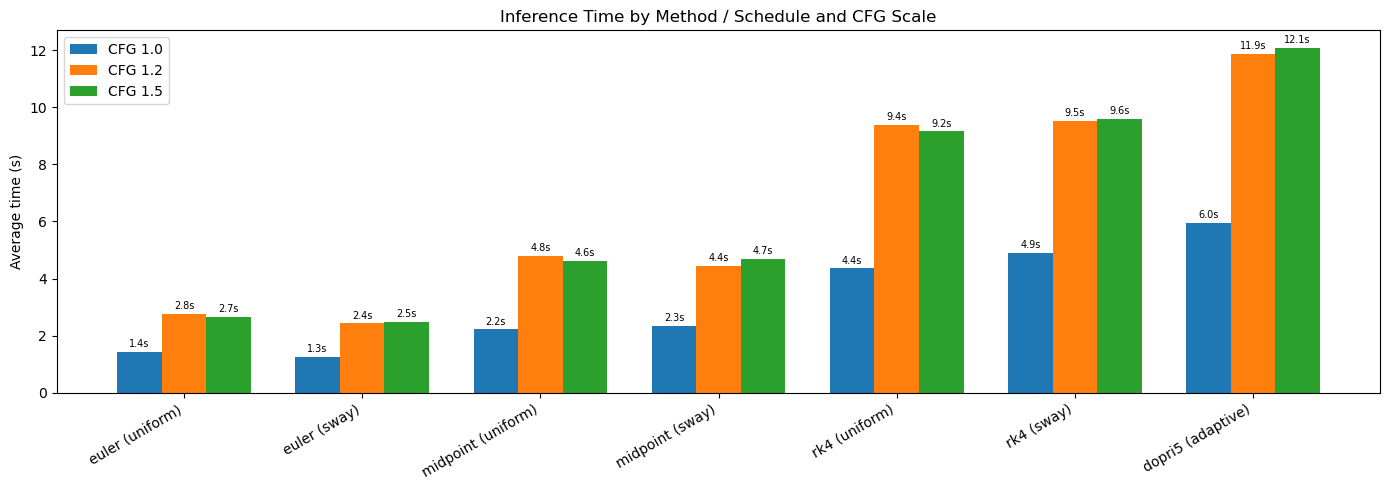

In [11]:
# ── Timing bar chart ──

time_rows = []
for si in range(len(all_samples)):
    for (method, sched), row_label in zip(CONFIG_ROWS, ROW_LABELS):
        for cfg in CFG_SCALES:
            time_rows.append({
                "Method": row_label, "CFG": cfg,
                "Time (s)": timings[si][(method, sched, cfg)],
            })

time_df = pd.DataFrame(time_rows)
avg_time = time_df.groupby(["Method", "CFG"])["Time (s)"].mean().unstack("CFG")
# Reorder rows to match CONFIG_ROWS order
avg_time = avg_time.reindex(ROW_LABELS)

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(ROW_LABELS))
width = 0.25

for i, cfg in enumerate(CFG_SCALES):
    bars = ax.bar(x + i * width, avg_time[cfg], width, label=f"CFG {cfg}")
    for bar, val in zip(bars, avg_time[cfg]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                f"{val:.1f}s", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x + width)
ax.set_xticklabels(ROW_LABELS, rotation=30, ha="right")
ax.set_ylabel("Average time (s)")
ax.set_title("Inference Time by Method / Schedule and CFG Scale")
ax.legend()
plt.tight_layout()
plt.show()